Import Libraries

In [390]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Load/Clean Data

In [391]:
dataset_path = "WM811k_Dataset"

class_names = [
    "Center",
    "Donut",
    "Edge Local",
    "Edge Ring",
    "Local",
    "near full",
    "none",
    "random",
    "Scratch"
]

image_size = (32, 32)

X_images = []
y_labels = []
file_paths = []

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    
    if not os.path.exists(class_folder):
        print(f"Missing folder: {class_folder}")
        continue
    
    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith(".jpg"):
            img_path = os.path.join(class_folder, file_name)
            
            try:
                img = Image.open(img_path).convert("L")   # grayscale
                img = img.resize(image_size)
                img_array = np.array(img)
                
                X_images.append(img_array)
                y_labels.append(class_name)
                file_paths.append(img_path)
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

X_images = np.array(X_images)
y_labels = np.array(y_labels)

print("Loaded images:", len(X_images))
print("Image array shape:", X_images.shape)
print("Label array shape:", y_labels.shape)

Loaded images: 902
Image array shape: (902, 32, 32)
Label array shape: (902,)


In [392]:
unique_classes, counts = np.unique(y_labels, return_counts=True)

for cls, count in zip(unique_classes, counts):
    print(f"{cls}: {count}")

Center: 100
Donut: 102
Edge Local: 103
Edge Ring: 102
Local: 100
Scratch: 100
near full: 95
none: 100
random: 100


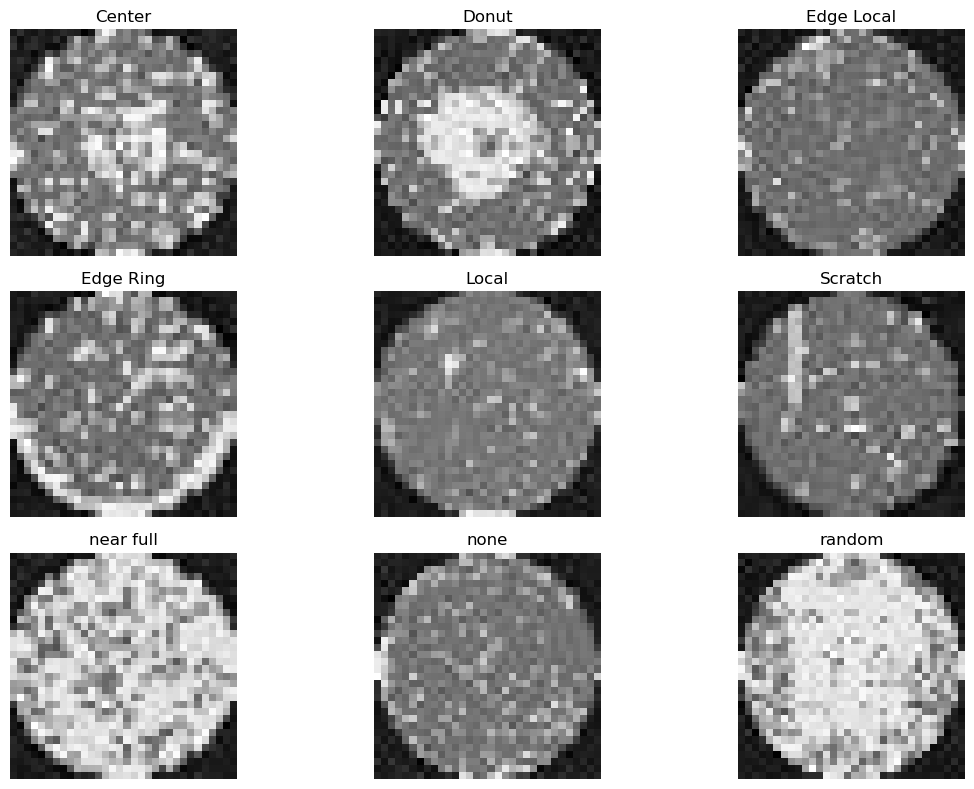

In [393]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(unique_classes):
    idx = np.where(y_labels == class_name)[0][0]
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_images[idx], cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [394]:
X = X_images.reshape(X_images.shape[0], -1)
print("Flattened X shape:", X.shape)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Flattened X shape: (902, 1024)
Class mapping:
0 -> Center
1 -> Donut
2 -> Edge Local
3 -> Edge Ring
4 -> Local
5 -> Scratch
6 -> near full
7 -> none
8 -> random


In [395]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

X_train: (721, 1024)
X_test: (181, 1024)
y_train: (721,)
y_test: (181,)
Scaled training shape: (721, 1024)
Scaled test shape: (181, 1024)


#### Fit Machine Learning Model (SVM)

In [396]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

In [397]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.7845303867403315

Classification Report:

              precision    recall  f1-score   support

      Center       0.50      0.35      0.41        20
       Donut       0.84      0.80      0.82        20
  Edge Local       0.79      0.90      0.84        21
   Edge Ring       0.86      0.86      0.86        21
       Local       0.86      0.60      0.71        20
     Scratch       0.58      0.70      0.64        20
   near full       0.90      1.00      0.95        19
        none       0.83      1.00      0.91        20
      random       0.85      0.85      0.85        20

    accuracy                           0.78       181
   macro avg       0.78      0.78      0.78       181
weighted avg       0.78      0.78      0.78       181



#### Model Insights
The SVM model achieved an overall accuracy of 78%, indicating that it is able to correctly classify most wafer defect images.

**Strong Classes:**  
Certain defect types such as “near full” (recall = 1.00, F1 = 0.95) and “none” (recall = 1.00, F1 = 0.91) are classified with very high accuracy.

**Moderate Classes:**  
Classes such as Edge Ring (F1 = 0.86), Edge Local (F1 = 0.84), and random (F1 = 0.85) also perform well.

**Challenging Class:**  
The model struggles more with certain classes, particularly Center (recall = 0.35, F1 = 0.41) and Scratch (F1 = 0.64). The model misses many Center defects (low recall), and when it does predict Center, it is only correct about 50% of the time (moderate precision).

In [398]:
center_idx = label_encoder.transform(["Center"])[0]

# indices where true label is Center
center_samples = np.where(y_test == center_idx)[0]

print("Total Center samples:", len(center_samples))

# get predictions for those samples
center_preds = y_pred[center_samples]

# count what they were predicted as
unique_preds, counts = np.unique(center_preds, return_counts=True)

print("\nPredictions for Center images:\n")

for pred_class, count in zip(unique_preds, counts):
    class_name = label_encoder.inverse_transform([pred_class])[0]
    print(f"Predicted as {class_name}: {count}")

Total Center samples: 20

Predictions for Center images:

Predicted as Center: 7
Predicted as Donut: 1
Predicted as Edge Local: 1
Predicted as Edge Ring: 3
Predicted as Local: 1
Predicted as Scratch: 4
Predicted as none: 3


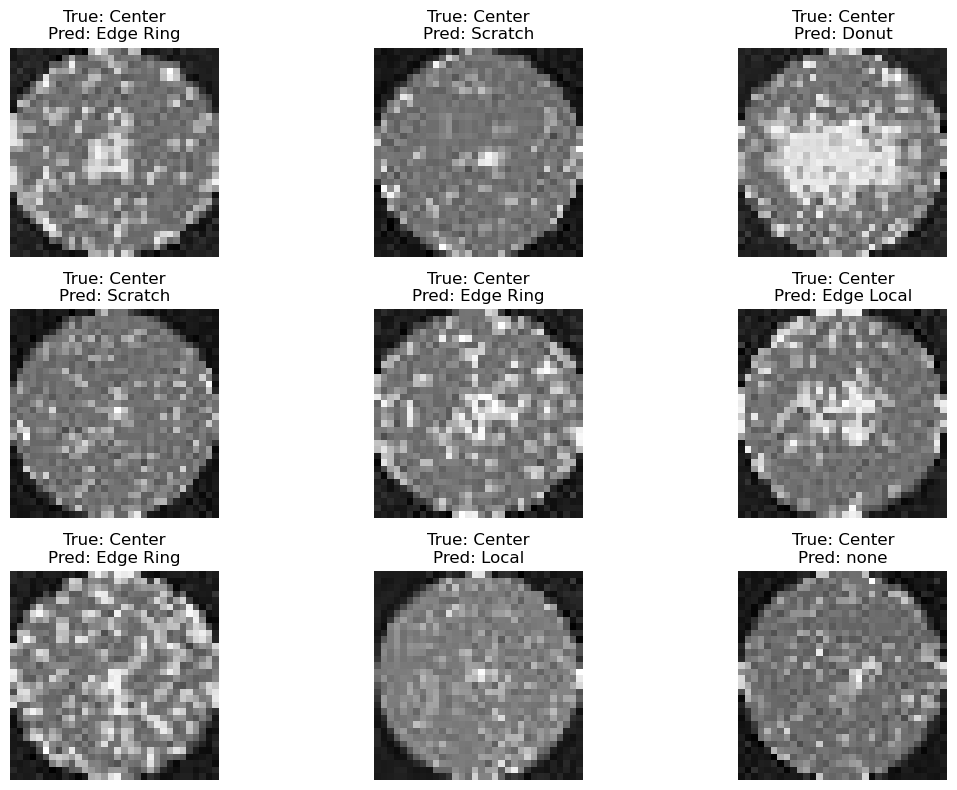

In [399]:
wrong_center_idx = center_samples[y_pred[center_samples] != center_idx]

plt.figure(figsize=(12, 8))

num_show = min(9, len(wrong_center_idx))

for i in range(num_show):
    idx = wrong_center_idx[i]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx].reshape(image_size), cmap="gray")
    
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred[idx]])[0]
    
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Improve Model Parameters (C = 2)

In [400]:
svm_model = SVC(
    kernel="rbf",
    C=2,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

In [401]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8287292817679558

Classification Report:

              precision    recall  f1-score   support

      Center       0.59      0.50      0.54        20
       Donut       0.85      0.85      0.85        20
  Edge Local       0.80      0.95      0.87        21
   Edge Ring       0.86      0.86      0.86        21
       Local       0.88      0.75      0.81        20
     Scratch       0.76      0.65      0.70        20
   near full       0.95      1.00      0.97        19
        none       0.83      1.00      0.91        20
      random       0.90      0.90      0.90        20

    accuracy                           0.83       181
   macro avg       0.83      0.83      0.82       181
weighted avg       0.82      0.83      0.82       181



Confusion Matrix of Actual vs. Predicted

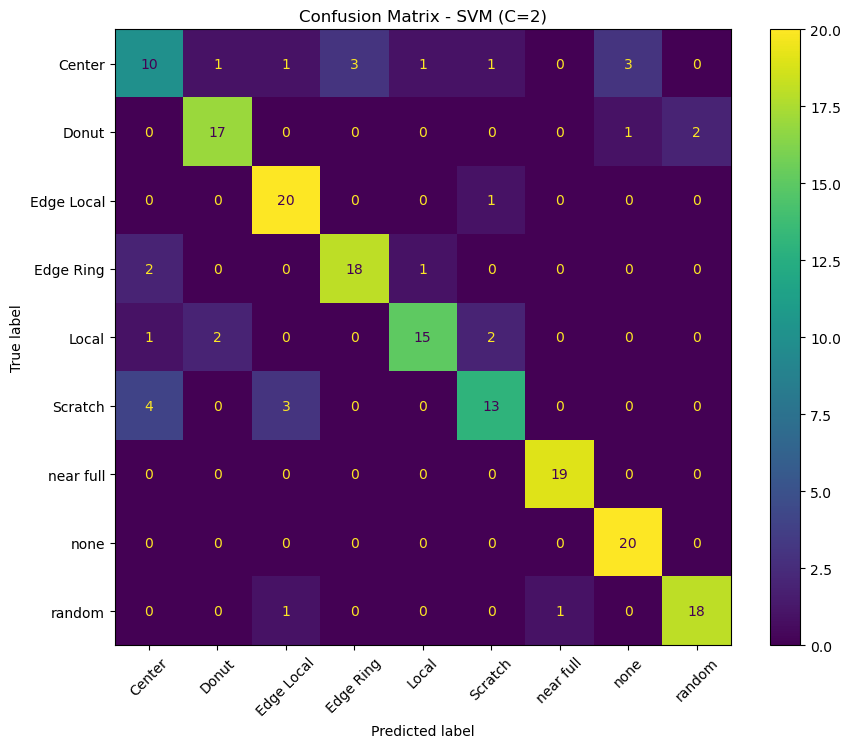

In [402]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - SVM (C=2)")
plt.show()

Model Improvements (PCA Application to Reduce Dimensionality)
- Compress data into 35 important features

In [403]:
from sklearn.decomposition import PCA

pca = PCA(n_components=35)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [404]:
svm_model = SVC(kernel="rbf", C=2, gamma="scale")

svm_model.fit(X_train_pca, y_train)
y_pred_pca = svm_model.predict(X_test_pca)

In [405]:
print("Accuracy:", accuracy_score(y_test, y_pred_pca))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_pca, target_names=label_encoder.classes_))

Accuracy: 0.861878453038674

Classification Report:

              precision    recall  f1-score   support

      Center       0.76      0.65      0.70        20
       Donut       0.89      0.85      0.87        20
  Edge Local       0.95      0.90      0.93        21
   Edge Ring       0.90      0.86      0.88        21
       Local       0.81      0.65      0.72        20
     Scratch       0.73      0.95      0.83        20
   near full       0.95      1.00      0.97        19
        none       0.83      1.00      0.91        20
      random       0.95      0.90      0.92        20

    accuracy                           0.86       181
   macro avg       0.86      0.86      0.86       181
weighted avg       0.87      0.86      0.86       181



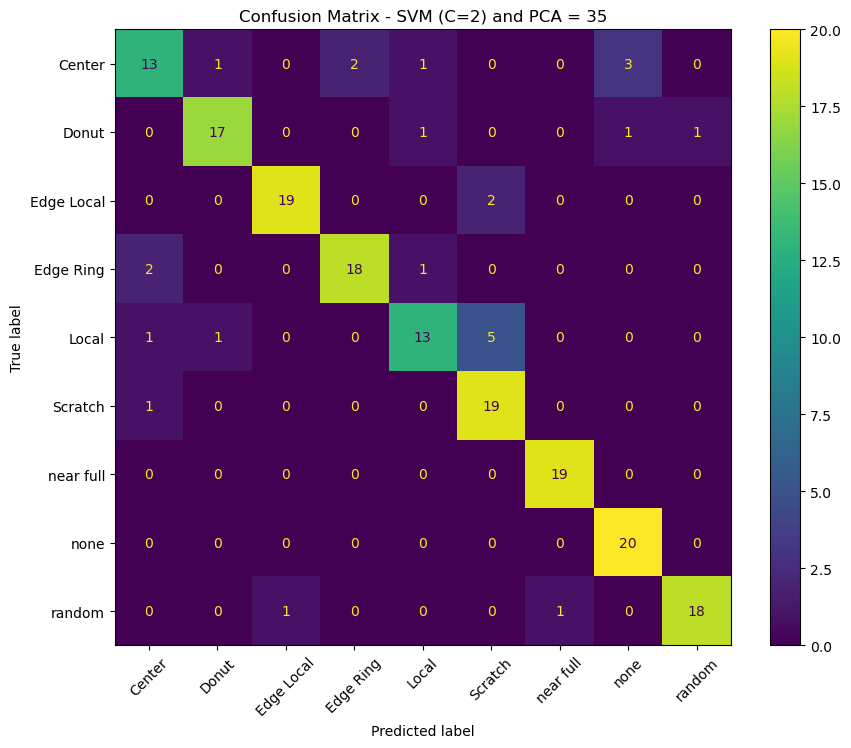

In [406]:
cm2 = confusion_matrix(y_test, y_pred_pca)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - SVM (C=2) and PCA = 35")
plt.show()

Accuracy improved to 86% with PCA = 35

#### Model Not Covered in Class: Nonlinear Dimensionality Reduction Technique t-SNE

In [407]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_test_pca)

print(X_tsne.shape)

(181, 2)


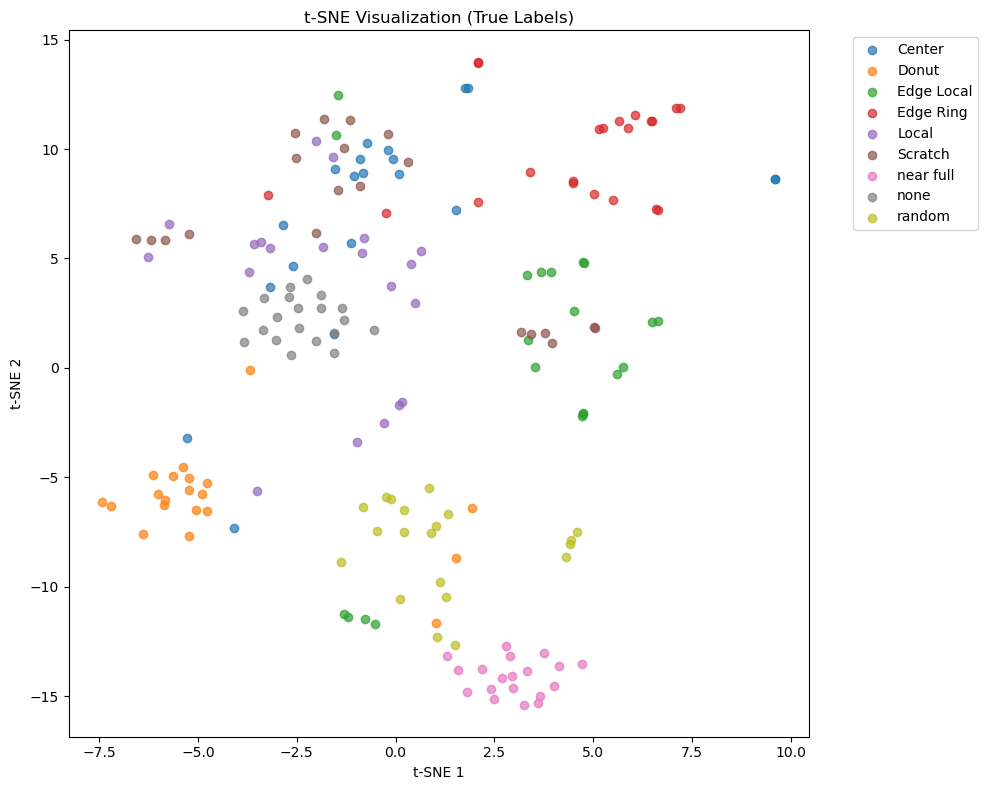

In [408]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for class_idx, class_name in enumerate(label_encoder.classes_):
    idx = np.where(y_test == class_idx)[0]
    
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=class_name,
        alpha=0.7
    )

plt.title("t-SNE Visualization (True Labels)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

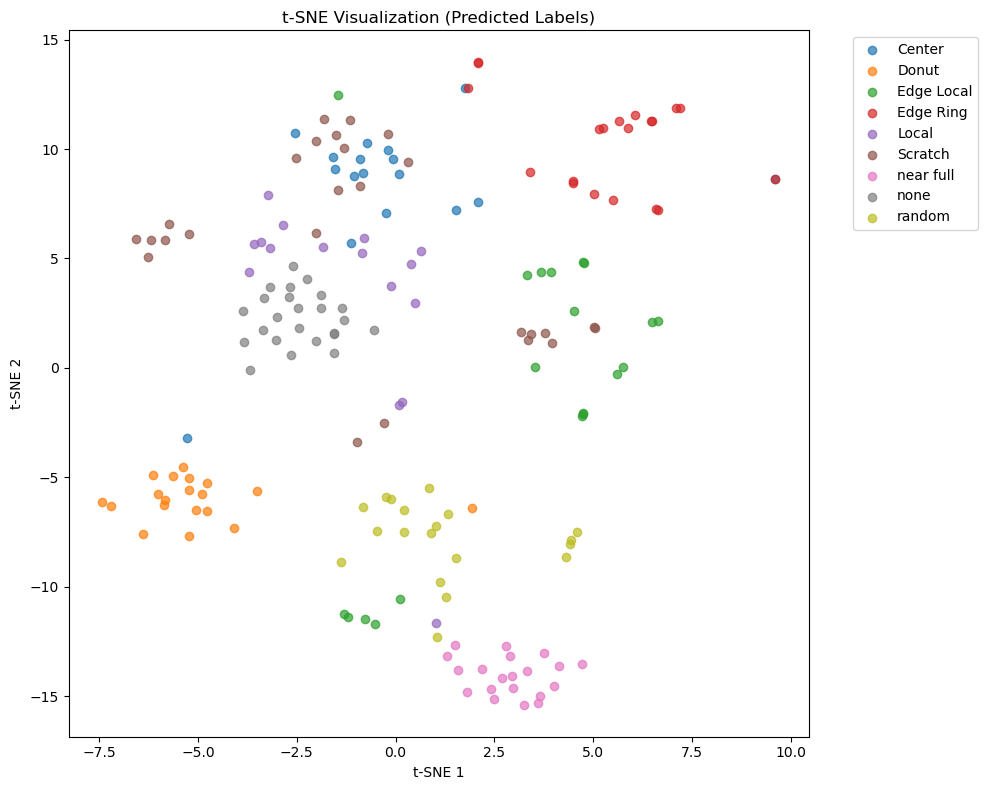

In [409]:
plt.figure(figsize=(10, 8))

for class_idx, class_name in enumerate(label_encoder.classes_):
    idx = np.where(y_pred_pca == class_idx)[0]
    
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=class_name,
        alpha=0.7
    )

plt.title("t-SNE Visualization (Predicted Labels)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

By comparing the true and predicted label visualizations, it can be observed that the model accurately captures well-separated clusters but struggles in regions where classes overlap such as Center overlapping with Scratch and Edge Ring. This demonstrates that the limitations in classification performance are not solely due to the model itself, but are also influenced by the intrinsic structure of the data.